# **Μερική Διαφορική Εξίσωση Burgers' (1939)**

### *Γενική μορφή της ιξώδης (viscous) ΜΔΕ Burgers'*

$$
u_t + uu_x = vu_{xx}
$$

---

### *Τα σύμβολα:*
$$u(x,t)=u \text{: ταχύτητα ροής ρευστού}$$
$$u_t \text{: ρυθμός μεταβολής ταχύτητα}$$
$$uu_x \text{: μη γραμμική διάδοση}$$
$$vu_{xx} \text{: διάχυση}$$
$$v \text{: συντελεστής διάχυσης/ιξώδους}$$


---

### **Προσεγγίζουμε την ΜΔΕ Burgers':**

$$
u_t + uu_x = vu_{xx}
$$

**με**

$$v=\frac{10^{-2}}{π}$$

$$x \in [-L,L]=[-1,1]$$

$$t \in [0,T]=[0,1]$$

---

### **Αρχική συνθήκη:**

$$
u(x,0) = -sin(πx)
$$

---

### **Συνοριακές συνθήκες: (Dirichlet)**

$$u(-1,t)=0$$

$$u(1,t)=0$$

In [1]:
import torch #βασικό πακέτο PyTorch
import torch.nn as nn #έτοιμες συναρτήσεις για νν
import torch.nn.functional as f #συναρτήσεις ενεργοποίησης
import torch.optim as optim #βελτιστοποιητές
import numpy as np #βιβλιοθήκη αριθμητικών υπολογισμών
from time import time #μέτρηση χρόνου
import gc #για καθαρισμό cpu
import platform #για το τι συσκευή cpu χρησιμοποιώ


use_cuda = input("Να κεράσω CUDA; (ναι/οχι): ").strip().lower()

if use_cuda == "ναι":
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
  device = torch.device("cpu")

print("Χρήση συσκευής:", device)
print(torch.__version__)

print(torch.cuda.is_available())
if torch.cuda.is_available():
  print("Κερασμένη η CUDA!")
  print("Current device:", torch.cuda.current_device())
  print("Device name:", torch.cuda.get_device_name(0))
  torch.cuda.empty_cache() # άδειασμα gpu
else:
  print("Μας τελείωσε η CUDA...")
  print(platform.uname())
  gc.collect() # άδειασμα cpu

#Ζέσταμα GPU για να μην πετάει warning
if device.type == "cuda":
    torch.cuda.init()
    torch.cuda.empty_cache()
    torch.randn(8, 8, device=device) #warm-up cuBLAS

Να κεράσω CUDA; (ναι/οχι): οχι
Χρήση συσκευής: cpu
2.10.0+cpu
False
Μας τελείωσε η CUDA...
uname_result(system='Linux', node='3541ccc7f8ea', release='6.6.113+', version='#1 SMP Mon Feb  2 12:27:57 UTC 2026', machine='x86_64')


In [2]:
#ορισμός ακρίβειας
dtype = torch.float32

#Σταθερές
pi = torch.tensor(np.pi, dtype=dtype, device=device) #π
viscosity = torch.tensor(10**(-2)/np.pi, dtype=dtype, device=device) #v διάχυση
L = 1 #πλάτος χώρου
L_min = torch.tensor(-L, dtype=dtype, device=device) #πλάτος χώρου ελάχιστο
L_max = torch.tensor(L, dtype=dtype, device=device) #πλάτος χώρου μεγιστο
T = torch.tensor(1, dtype=dtype, device=device) #χρόνος

#Αρχική Συνθήκη
def fun_u_0(t,x):
  return -torch.sin(pi*x)

#Συνοριακές Συνθήκες
def fun_u_b_left(t,x):
  n = t.shape[0] #πλήθος γραμμών
  return torch.zeros((n,1), dtype=dtype, device=device)

def fun_u_b_right(t,x):
  n = t.shape[0] #πλήθος γραμμών
  return torch.zeros((n,1), dtype=dtype, device=device)

#ΜΔΕ Εξίσωση Burgers'
def fun_r(u, u_t, u_x, u_xx):
    return u_t + u * u_x - viscosity * u_xx


In [3]:
#Αριθμός σημείων
N_0 = 400 #πλήθος αρχικής συνθήκες u(x,0)
N_b = 500 #πλήθος συνοριακών συνθηκών u(±1, t)
N_r = 2000 #πλήθος στο εσωτερικό του πεδίου εκπαίδευσης της ΜΔΕ

#Συνοριακές τιμές
tmin = torch.tensor(0, dtype=dtype, device=device)
tmax = T
xmin = L_min
xmax = L_max

In [4]:
print(f'Τα όρια του χωροχρονικού πεδίου σε μορφή tensor:\n')
print(f'[tmin,tmax] x [xmin,xmax]')
print(f'[{tmin}, {tmax.item()}] x [{xmin.item()}, {xmax.item()}]\n')


Τα όρια του χωροχρονικού πεδίου σε μορφή tensor:

[tmin,tmax] x [xmin,xmax]
[0.0, 1.0] x [-1.0, 1.0]



In [5]:
#Κάτω όριο
lb = torch.tensor([tmin, xmin], dtype=dtype, device=device)
#Πάνω όριο
ub = torch.tensor([tmax, xmax], dtype=dtype, device=device)

In [6]:
print(f'lb:', lb.device)
print(f'ub:', ub.device)

lb: cpu
ub: cpu


In [7]:
#Σταθεροποίηση γεννήτριας τυχαίων αριθμών
torch.manual_seed(67)

In [8]:
#Δημιουργία σημείων αρχικών συνθηκών


#στήλη με την αρχική τιμή του χρόνου
###t_0 = torch.ones((N_0,1), dtype=dtype, requires_grad=True, device=device)*lb[0]
t_0 = torch.ones((N_0,1), dtype=dtype, device=device)*lb[0]

#στήλη με τυχαίους στο διάστημα [xmin,xmax]
###x_0 = torch.rand((N_0,1), dtype=dtype, requires_grad=True, device=device)*(ub[1]-lb[1]) + lb[1]
x_0 = torch.rand((N_0,1), dtype=dtype, device=device)*(ub[1]-lb[1]) + lb[1]

#Συνδιασμός σε tensor (N0,2) ##δύο στήλες t0,x0
X_0 = torch.concat([t_0, x_0], dim=1)

In [9]:
print(f't_0: ',t_0.shape)
print(f'x_0: ',x_0.shape)
print(f'X_0: ',X_0.shape)
print(f't_0: ',t_0.device)
print(f'x_0: ',x_0.device)
print(f'X_0: ',X_0.device)

t_0:  torch.Size([400, 1])
x_0:  torch.Size([400, 1])
X_0:  torch.Size([400, 2])
t_0:  cpu
x_0:  cpu
X_0:  cpu


In [10]:
#Υπολογισμός αρχικής συνθήκης
u_0 = fun_u_0(t_0, x_0)

In [11]:
print(f'u_0: ',u_0.shape)
print(f'u_0: ',u_0.device)

u_0:  torch.Size([400, 1])
u_0:  cpu


In [12]:
# Δημιουργία σημείων συνοριακών συνθηκών


#στήλη με τυχαίους στο διάστημα [tmin, tmax]
###t_b = torch.rand((N_b,1), dtype=dtype, requires_grad=True, device=device)*(ub[0]-lb[0]) + lb[0]
t_b = torch.rand((N_b,1), dtype=dtype, device=device)*(ub[0]-lb[0]) + lb[0]

#στήλη με N_b στοιχεία για το xmin σύνορο (αριστερά)
###x_b_left = torch.ones((N_b, 1), dtype=dtype, requires_grad=True, device=device)*lb[1]
x_b_left = torch.ones((N_b, 1), dtype=dtype, device=device)*lb[1]

#στήλη με N_b στοιχεία για το xmax σύνορο (δεξιά)
###x_b_right = torch.ones((N_b, 1), dtype=dtype, requires_grad=True, device=device)*ub[1]
x_b_right = torch.ones((N_b, 1), dtype=dtype, device=device)*ub[1]

#Συνδιασμός σε tensor (N_b,2)
X_b = torch.concat([t_b, x_b_left, x_b_right], axis=1)

In [13]:
print(f't_b:       ',t_b.shape)
print(f'x_b_left:  ',x_b_left.shape)
print(f'x_b_right: ',x_b_right.shape)
print(f'X_b:       ',X_b.shape)
print(f't_b:       ',t_b.device)
print(f'x_b_left:  ',x_b_left.device)
print(f'x_b_right: ',x_b_right.device)
print(f'X_b:       ',X_b.device)

t_b:        torch.Size([500, 1])
x_b_left:   torch.Size([500, 1])
x_b_right:  torch.Size([500, 1])
X_b:        torch.Size([500, 3])
t_b:        cpu
x_b_left:   cpu
x_b_right:  cpu
X_b:        cpu


In [14]:
#Υπολογισμός Συνοριακών Συνθηκών

#Αριστερό σύνορο
u_b_left = fun_u_b_left(t_b, x_b_left)

#Δεξί σύνορο
u_b_right = fun_u_b_right(t_b, x_b_right)

#Συνδιασμός σε tensor (N_b,1)
u_b = torch.concat([u_b_left, u_b_right], axis=1)

In [15]:
print(f'u_b_left:  ',u_b_left.shape)
print(f'u_b_right: ',u_b_right.shape)
print(f'u_b:       ',u_b.shape)
print(f'u_b_left:  ',u_b_left.device)
print(f'u_b_right: ',u_b_right.device)
print(f'u_b:       ',u_b.device)

u_b_left:   torch.Size([500, 1])
u_b_right:  torch.Size([500, 1])
u_b:        torch.Size([500, 2])
u_b_left:   cpu
u_b_right:  cpu
u_b:        cpu


In [16]:
#Τυχαία σημεία λύσης

#Δημιουργία τυχαίων τιμών στο χρόνο [tmin, tmax]
t_r = torch.rand((N_r,1), dtype=dtype, requires_grad=True, device=device)*(ub[0]-lb[0]) + lb[0]

#Δημιουργία τυχαίων τιμών στο χώρο [xmin, xmax]
x_r = torch.rand((N_r,1), dtype=dtype, requires_grad=True, device=device)*(ub[1]-lb[1]) + lb[1]

#Συνδιασμός σημείων σε tensor (N_r,2)
X_r = torch.concat([t_r, x_r], axis=1)

In [17]:
print(f't_r: ',t_r.shape)
print(f'x_r: ',x_r.shape)
print(f'X_r: ',X_r.shape)
print(f't_r: ',t_r.device)
print(f'x_r: ',x_r.device)
print(f'X_r: ',X_r.device)

t_r:  torch.Size([2000, 1])
x_r:  torch.Size([2000, 1])
X_r:  torch.Size([2000, 2])
t_r:  cpu
x_r:  cpu
X_r:  cpu


In [18]:
#λίστες

#(Ν_0,2) αρχικά σημεία, (Ν_b,3) συνοριακά σημεία
X_data = [X_0, X_b]

#(Ν_0,1) αρχικές τιμές, (Ν_b,2) συνοριακές τιμές
u_data = [u_0, u_b]

In [19]:
print(f'X_data[0]==X_0: ',X_data[0].shape)
print(f'X_data[1]==X_b: ',X_data[1].shape)
print(f'u_data[0]==u_0: ',u_data[0].shape)
print(f'u_data[1]==u_b: ',u_data[1].shape)
print(f'X_data[0]==X_0: ',X_data[0].device)
print(f'X_data[1]==X_b: ',X_data[1].device)
print(f'u_data[0]==u_0: ',u_data[0].device)
print(f'u_data[1]==u_b: ',u_data[1].device)

X_data[0]==X_0:  torch.Size([400, 2])
X_data[1]==X_b:  torch.Size([500, 3])
u_data[0]==u_0:  torch.Size([400, 1])
u_data[1]==u_b:  torch.Size([500, 2])
X_data[0]==X_0:  cpu
X_data[1]==X_b:  cpu
u_data[0]==u_0:  cpu
u_data[1]==u_b:  cpu


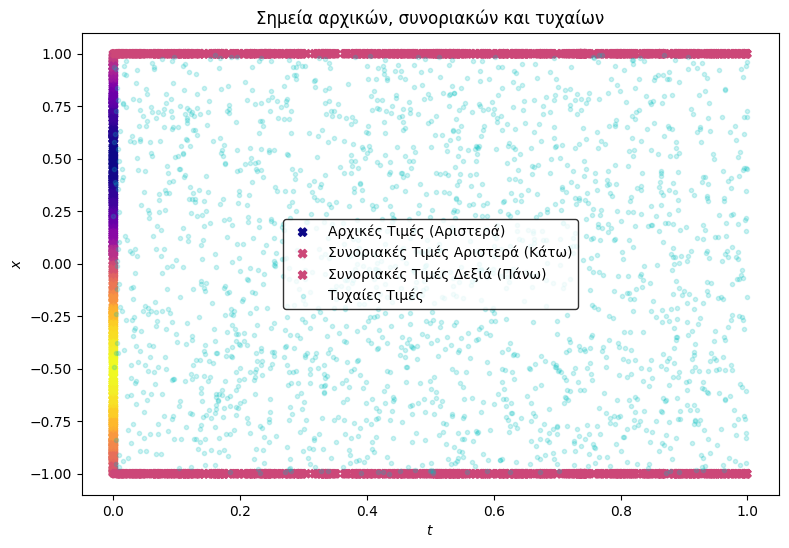

In [20]:
import matplotlib.pyplot as plt #βιβλιοθήκη γραφήματα

fig = plt.figure(figsize=(9,6)) #καμβάς 9x6 ίντσες
color = 'plasma' #επιλογή χρώματος γραφίματος


#σημεία αρχικής συνθήκης
plt.scatter(t_0.cpu().detach(), x_0.cpu().detach(), c=u_0.cpu().detach(), marker='X', vmin=-1, vmax=1, cmap=color, label='Αρχικές Τιμές (Αριστερά)')

#σημεία συνοριακών συνθηκών
plt.scatter(t_b.cpu().detach(), x_b_left.cpu().detach(), c=u_b[:,[0]].cpu().detach(), marker='X', vmin=-1, vmax=1, cmap=color, label='Συνοριακές Τιμές Αριστερά (Κάτω)')
plt.scatter(t_b.cpu().detach(), x_b_right.cpu().detach(), c=u_b[:,[1]].cpu().detach(), marker='X', vmin=-1, vmax=1, cmap=color, label='Συνοριακές Τιμές Δεξιά (Πάνω)')

#σημεία τυχαία
plt.scatter(t_r.cpu().detach(), x_r.cpu().detach(), c='c', marker='.', alpha=0.2, label='Τυχαίες Τιμές')

plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend(loc='center').get_frame().set_edgecolor('black')
plt.title('Σημεία αρχικών, συνοριακών και τυχαίων');

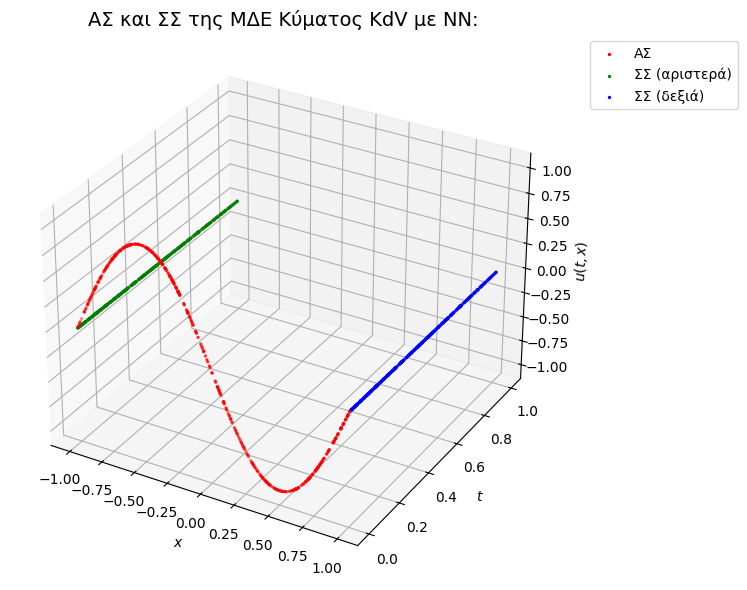

Στο t=Τ έχουμε min U_0 = -1.000, max U_0 = 1.000


In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

#Αρχική Συνθήκη
ax.scatter(x_0.detach().cpu().numpy(), t_0.detach().cpu().numpy(), u_0.detach().cpu().numpy(), color='r', label='ΑΣ', s=2);

#Συνοριακή Συνθήκη (Αριστερά)
ax.scatter(x_b_left.detach().cpu().numpy(), t_b.detach().cpu().numpy(), u_b_left.detach().cpu().numpy(), color='g', label='ΣΣ (αριστερά)', s=2);

#Συνοριακή Συνθήκη (Δεξιά)
ax.scatter(x_b_right.detach().cpu().numpy(), t_b.detach().cpu().numpy(), u_b_right.detach().cpu().numpy(), color='b', label='ΣΣ (δεξιά)', s=2);


ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$u(t,x)$')
ax.set_title(r'ΑΣ και ΣΣ της ΜΔΕ Κύματος KdV με NN:', fontsize=14);
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Μέγιστο πλάτος στο t_max
U0_min = u_0.min().item()
U0_max = u_0.max().item()
print(f'Στο t=Τ έχουμε min U_0 = {U0_min:.3f}, max U_0 = {U0_max:.3f}')

In [22]:
#Δημιουργία ΝΝ

class NeuralNetwork(nn.Module):
    def __init__(self, num_hidden_layers=8, num_neurons_per_layer=20):
        super(NeuralNetwork, self).__init__()

        #Το input layer συνδέεται στο 1ο layer (με 20 νευρώνες)
        self.input_layer = nn.Linear(2, num_neurons_per_layer)

        #Τα layers από το 1ο μέχρι το 8ο
        self.hidden_layers = nn.ModuleList([
            nn.Linear(num_neurons_per_layer,num_neurons_per_layer)

            for _ in range(num_hidden_layers)
        ])

        #Το output layer δίνει πραγματική τιμή
        self.output_layer = nn.Linear(num_neurons_per_layer, 1)

        #Αρχικοποίηση βαρών
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.hidden_layers:
            #αποτρέπει τα πολύ μεγάλα και πολύ μικρά βάρη
            nn.init.xavier_normal_(layer.weight)

    def forward(self, x):
        # Μετασχηματιμσός του x για να βρίσκεται στο [lb[1], ub[1]]=[xmin,xmax]=[-1,1] για ταχύτερη επκπαίδευση με την tanh
        x = 2.0*(x - lb)/(ub - lb) - 1.0

        #Το input layer
        x = torch.tanh(self.input_layer(x))
        #1ο με 8ο hidden layer
        for layer in self.hidden_layers:
            x = torch.tanh(layer(x))
        #Το output layer
        x = self.output_layer(x)
        return x

In [23]:
#Υπολογισμός Απώλειας

def compute_loss(model, X_r, X_data, u_data, epochs, verbose_flag):

    ##Απώλεια ΜΔΕ
    #Σπάσιμο στηλών t,x για να υπολογιστούν ξεχωριστά οι μερικές παράγωγοι
    t = X_r[:,0:1]#.detach().requires_grad_(True)
    x = X_r[:,1:2]#.detach().requires_grad_(True)

    #Εκτίμηση ΜΔΕ μοντέλου
    u = model(torch.concat([t,x],dim=1))

    #Υπολογισμός Μερικών Παραγώγων
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),create_graph=True, allow_unused=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u),create_graph=True, allow_unused=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),create_graph=True, allow_unused=True)[0]

    #Υπολογισμός της απώλειας της ΜΔΕ
    l_u = torch.mean(torch.square(fun_r(u, u_t, u_x, u_xx)))


    ##Απώλεια αρχικής συνθήκης
    #Σπάσιμο στηλών t0,x0
    t0 = X_data[0][:,0:1]#.clone().detach().requires_grad_(True)
    x0 = X_data[0][:,1:2]#.detach().requires_grad_(True)

    #Εκτίμηση αρχικής τιμής μοντέλου
    u0 = model(torch.concat([t0,x0],dim=1))

    #Υπολογισμός της απώλειας της αρχικής συνθήκης
    l_0 = torch.mean(torch.square(u_data[0]-u0))


    ##Απώλεια συνοριακών τιμών Dirichlet
    #Σπάσιμο στηλών t,x για να υπολογιστούν ξεχωριστά οι μερικές παράγωγοι
    tb = X_data[1][:,0:1]#.clone().detach().requires_grad_(True)
    xbl = X_data[1][:,1:2]#.detach().requires_grad_(True)
    xbr = X_data[1][:,2:3]#.detach().requires_grad_(True)

    #Εκτίμηση μοντέλου Αριστερά
    ubl = model(torch.concat([tb, xbl],dim=1))

    #Εκτίμηση μοντέλου Δεξιά
    ubr = model(torch.concat([tb, xbr],dim=1))

    #Υπολογισμός της απώλειας των συνοριακών συνθηκών + παραγώγου
    l_left = torch.mean(torch.square(u_data[1][:,0:1]-ubl))
    l_right = torch.mean(torch.square(u_data[1][:,1:2]-ubr))
    l_b = l_left + l_right

    #Προσαρμογή Βαρών κάθε loss
    w_u = 1
    w_b = 10
    w_0 = 10

    #Ολική απώλεια
    loss = w_u * l_u + w_b * l_b + w_0 * l_0

    if (epochs % 100 == 0) and (verbose_flag != -1):
      print(f'Epoch {epochs:05d}: l_u = {l_u:10.8e}, l_b = {l_b:10.8e}, l_0 = {l_0:10.8e}, loss = {loss:10.8e}')

    return loss

In [24]:
model = NeuralNetwork().to(device)

# Έλεγχος ότι το μοντέλο πήγε στη GPU
print("Model is on:", next(model.parameters()).device)

#Σταθερά learning rate
lr_schedule = [5e-3, 1e-3, 1e-4]
def get_lr(epoch):
    if epoch < 100:
        return lr_schedule[0]
    elif epoch < 3000:
        return lr_schedule[1]
    else:
        return lr_schedule[2]

#Adam βελτιστοποιητής
optimizer = optim.Adam(model.parameters(), lr=lr_schedule[0])

Model is on: cpu


In [25]:
#Αριθμός εποχών
epochs=0
epoch = 2000
#Λίστα απώλειας κάθε εποχής
losses = []
#Καταγραφή χρόνου (σε δευτερόλεπτα)
sec = time()

for i in range(epoch):

    #Ενημέρωση της σταθεράς learning rate
    for param_group in optimizer.param_groups:
        param_group["lr"] = get_lr(i)

    #Μηδενισμός των παραγώγων του βελτιστοποιητή πριν το backpropagation
    optimizer.zero_grad()

    #Υπολογισμός σφάλματος
    loss = compute_loss(model, X_r, X_data, u_data, epochs, verbose_flag=1)

    #Υπολογισμός των παραγώγων τρέχουσας εποχής
    loss.backward(retain_graph=True)

    #Ενημέρωση βαρών επόμενης εποχής
    optimizer.step()

    #Αποθήκευση του σφάλματος κάθε εποχής
    losses.append(loss.item())

    #Για την εκτύπωση του loss
    epochs = epochs + 1

    #Εφαρμογή του early stopping
    if loss.item() < 1e-5:
       break

#Εμφάνιση χρόνου εκτέλεσης του μοντέλου
seconds = time() - sec
days = seconds // (24*60*60)
hours = (seconds % (24*60*60)) // (60*60)
minutes = (seconds % (60*60)) // 60
second = int(seconds % 60)
print(f'\nΧρόνος Εκπαίδευσης Μοντέλου: {int(days)} μέρες, {int(hours)} ώρες, {int(minutes)} λεπτά, {int(second)} δευτερόλεπτα')
print(f'\nEpochs: {epochs}, loss = {losses[epochs-1]:10.8e}')


Epoch 00000: l_u = 1.86494249e-03, l_b = 4.14198413e-02, l_0 = 4.85000163e-01, loss = 5.26606512e+00
Epoch 00100: l_u = 1.87218100e-01, l_b = 1.70658197e-04, l_0 = 3.64301447e-03, loss = 2.25354820e-01
Epoch 00200: l_u = 1.79788217e-01, l_b = 5.61316701e-05, l_0 = 3.56092001e-03, loss = 2.15958729e-01
Epoch 00300: l_u = 1.74270466e-01, l_b = 5.56516970e-05, l_0 = 3.46349319e-03, loss = 2.09461913e-01
Epoch 00400: l_u = 1.69920072e-01, l_b = 6.09229501e-05, l_0 = 3.36600374e-03, loss = 2.04189345e-01
Epoch 00500: l_u = 1.66304976e-01, l_b = 5.98601546e-05, l_0 = 3.27358302e-03, loss = 1.99639410e-01
Epoch 00600: l_u = 1.62936434e-01, l_b = 5.59560649e-05, l_0 = 3.18328431e-03, loss = 1.95328832e-01
Epoch 00700: l_u = 1.58915654e-01, l_b = 5.21742040e-05, l_0 = 3.07797128e-03, loss = 1.90217108e-01
Epoch 00800: l_u = 1.53118610e-01, l_b = 4.91746760e-05, l_0 = 2.94902315e-03, loss = 1.83100596e-01
Epoch 00900: l_u = 1.32238969e-01, l_b = 5.65724622e-05, l_0 = 2.54741823e-03, loss = 1.582

In [26]:
# Fine-tuning με L-BFGS
#Καταγραφή χρόνου (σε δευτερόλεπτα)
sec = time()

lbfgs_counter = 0  #μετρητής βημάτων LBFGS

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(),    #μεταβολή των βαρών του μοντέλου
                                    max_iter=500,          #μέγιστος αριθμός εσωτερικών βημάτων
                                    tolerance_grad=1e-7,   #έξοδος όταν η μέση κλίση είναι μικρότερη από
                                    tolerance_change=1e-9, #έξοδος όταν τα βάρη είναι μικρότερα από
                                    history_size=50,       #πόσα προηγούμενα βήματα να θυμάται για την εκτίμηση της Hessian
                                    line_search_fn="strong_wolfe") #για σταθερή σύγκλιση, αποφυγεί πολύ μικρών/μεγάλων βημάτων

def closure():
    optimizer_lbfgs.zero_grad() #μηδενισμός προηγούμενων gradients
    loss = compute_loss(model, X_r, X_data, u_data, epochs, verbose_flag=-1) #υπολογισμός απώλειας
    loss.backward(retain_graph=True) #υπολογισμός gradients
    global lbfgs_counter #για να την πάρει από έξω
    lbfgs_counter = lbfgs_counter + 1 #μετρητής βημάτων LBFGS
    return loss

#Μία κλήση LBFGS (κάνει εσωτερικά 500 αλληλεπιδράσεις)
optimizer_lbfgs.step(closure)

#Τελική αξιολόγηση μετά το LBFGS
loss_lbfgs = compute_loss(model, X_r, X_data, u_data, 0, verbose_flag=-1)

print(f"LBFGS Επανάληψη {lbfgs_counter}")
print(f"LBFGS Σφάλμα {loss_lbfgs.item():10.8e}")
print(f"LBFGS βελτίωση: Από {losses[-1]:10.8e} σε {loss_lbfgs.item():10.8e}")
print(f"Διαφορά LBFGS με Adam: {(loss_lbfgs.item() - losses[-1]):+10.8e}")

#Εμφάνιση χρόνου εκτέλεσης του LBFGS
seconds = time() - sec
days = seconds // (24*60*60)
hours = (seconds % (24*60*60)) // (60*60)
minutes = (seconds % (60*60)) // 60
second = int(seconds % 60)
print(f'\nΧρόνος Βελτιστοποίησης με LBFGS: {int(days)} μέρες, {int(hours)} ώρες, {int(minutes)} λεπτά, {int(second)} δευτερόλεπτα')

LBFGS Επανάληψη 535
LBFGS Σφάλμα 2.19817230e-04
LBFGS βελτίωση: Από 5.32015087e-03 σε 2.19817230e-04
Διαφορά LBFGS με Adam: -5.10033364e-03

Χρόνος Βελτιστοποίησης με LBFGS: 0 μέρες, 0 ώρες, 0 λεπτά, 20 δευτερόλεπτα


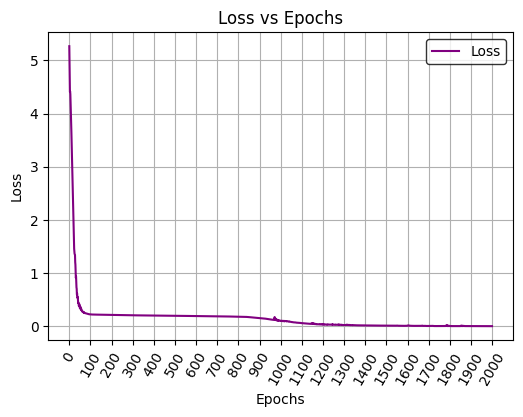

In [27]:
#Απώλεια κάθε εποχής
fig = plt.figure(figsize=(6,4))

plt.plot(range(epochs), losses, label='Loss', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend(loc='upper right').get_frame().set_edgecolor('black')
plt.xticks(range(0, epoch+1, 100), rotation=60)
plt.grid(True)
plt.show()

u0_m:  torch.Size([400, 1])
ubl_m:  torch.Size([500, 1])
ubr_m:  torch.Size([500, 1])


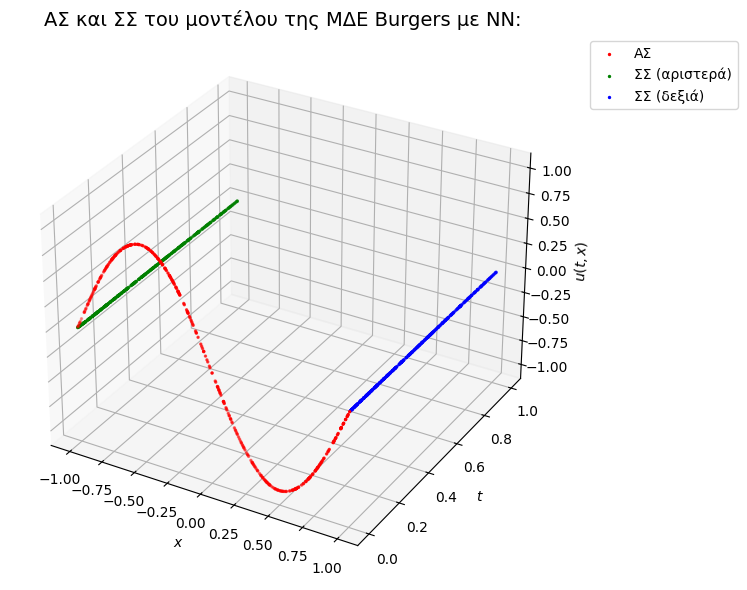

Στο t=Τ έχουμε min U_0 = -1.002, max U_0 = 1.000


In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

#Τελική εκτίμηση μοντέλου Αρχικής Συνθήκης
u0_m = model(torch.concat([t_0, x_0],dim=1))
print(f'u0_m: ',u0_m.shape)

#Τελική εκτίμηση μοντέλου Συνοριακής Συνθήκης Αριστερά
ubl_m = model(torch.concat([t_b, x_b_left],dim=1))
print(f'ubl_m: ',ubl_m.shape)

#Τελική εκτίμηση μοντέλου Συνοριακής Συνθήκης Δεξιά
ubr_m = model(torch.concat([t_b, x_b_right],dim=1))
print(f'ubr_m: ',ubr_m.shape)

#Αρχική Συνθήκη
ax.scatter(x_0.detach().cpu().numpy(), t_0.detach().cpu().numpy(), u0_m.detach().cpu().numpy(), color='r', label='ΑΣ', s=2);

#Συνοριακή Συνθήκη (Αριστερά)
ax.scatter(x_b_left.detach().cpu().numpy(), t_b.detach().cpu().numpy(), ubl_m.detach().cpu().numpy(), color='g', label='ΣΣ (αριστερά)', s=2);

#Συνοριακή Συνθήκη (Δεξιά)
ax.scatter(x_b_right.detach().cpu().numpy(), t_b.detach().cpu().numpy(), ubr_m.detach().cpu().numpy(), color='b', label='ΣΣ (δεξιά)', s=2);


ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$u(t,x)$')
ax.set_title(r'ΑΣ και ΣΣ του μοντέλου της ΜΔΕ Burgers με NN:', fontsize=14);
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Μέγιστο πλάτος στο t_max
U0_min = u0_m.min().item()
U0_max = u0_m.max().item()
print(f'Στο t=Τ έχουμε min U_0 = {U0_min:.3f}, max U_0 = {U0_max:.3f}')

Για t=[0,T] έχουμε min U = -1.002, max U = 1.000
Στο t=Τ έχουμε min U = -0.716, max U = 0.710


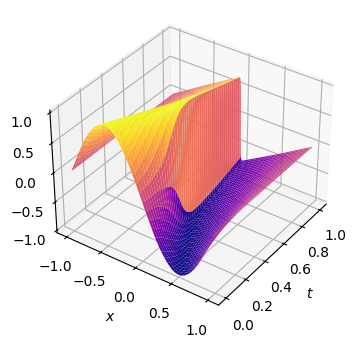

In [29]:
from mpl_toolkits.mplot3d import Axes3D #βιβλιοθήκη για 3D γραφήματα

#Πλήθος διαστημάτων
N = 1000

tmin = tmin.cpu().item()
tmax = tmax.cpu().item()
xmin = xmin.cpu().item()
xmax = xmax.cpu().item()

#Δημιουργία σημείων
tspace = np.linspace(tmin, tmax, N + 1) #(N+1,1)
xspace = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T, X = np.meshgrid(tspace, xspace) #(N+1,N+1) , (N+1,N+1)

#κάθε γραμμή ένα σημείο του πλέγματος
Xgrid = np.vstack([T.flatten(),X.flatten()]).T #((Ν+1)^2,2)

#Υπολογίζει τις προβλέψεις u(t, x) του μοντέλου
upred = model(torch.tensor(Xgrid,dtype=dtype).to(device)) #((Ν+1)^2,1)

#Από ((Ν+1)^2,1) σε (Ν+1,Ν+1)
U = upred.cpu().detach().numpy().reshape(N+1,N+1)

#Γράφημα πρόβλεψης u(t,x) από δύο οπτικές γωνίες
fig = plt.figure(figsize=(6,4))
#fig.suptitle('Μοντελοποίηση ΜΔΕ Περιοδικού Κύματος με NN:\n Αποτελέσματα Προβλέψεων', fontsize=14)

ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_surface(T, X, U, cmap='plasma');
ax1.view_init(35,35)
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_zlabel('$u(t,x)$')

ax1.invert_xaxis()


print(f'Για t=[0,T] έχουμε min U = {U.min():.3f}, max U = {U.max():.3f}')

# Τελικό χρονικό βήμα
U_final = U[:,-1]  # τελευταία γραμμή

# Μέγιστο πλάτος στο t_max
U_min = np.min(U_final)
U_max = np.max(U_final)
print(f'Στο t=Τ έχουμε min U = {U_min:.3f}, max U = {U_max:.3f}')

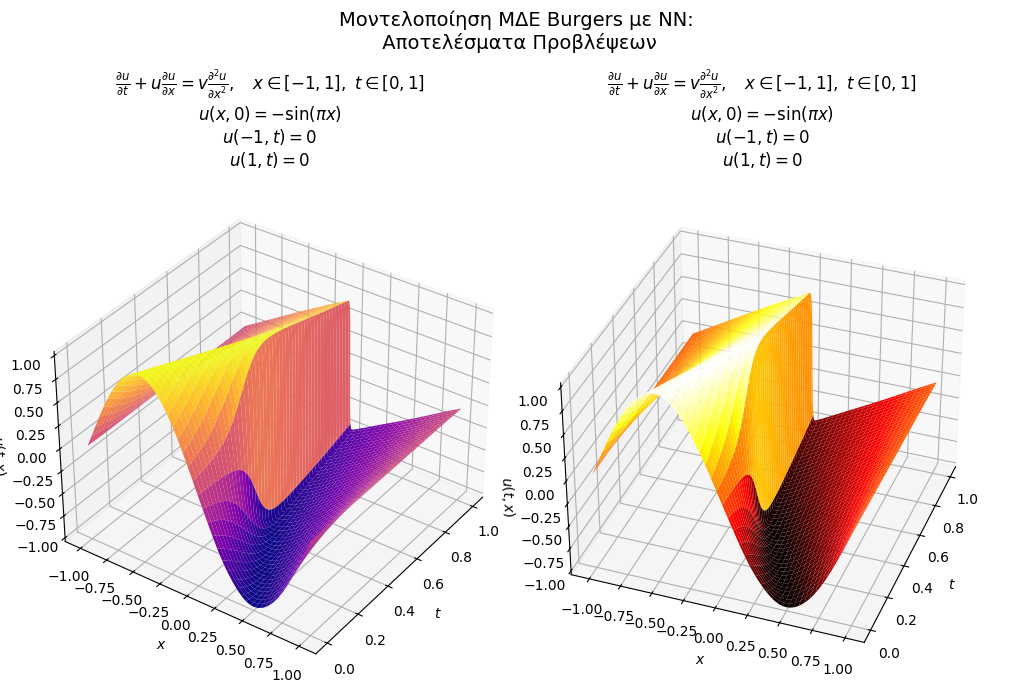

Για t=[0,T] έχουμε min U = -1.002, max U = 1.000
Στο t=Τ έχουμε min U = -0.716, max U = 0.710


In [30]:
from mpl_toolkits.mplot3d import Axes3D #βιβλιοθήκη για 3D γραφήματα

#Πλήθος διαστημάτων
N = 1000

#tmin = tmin.cpu().item()
#tmax = tmax.cpu().item()
#xmin = xmin.cpu().item()
#xmax = xmax.cpu().item()

#Δημιουργία σημείων
tspace = np.linspace(tmin, tmax, N + 1) #(N+1,1)
xspace = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T, X = np.meshgrid(tspace, xspace) #(N+1,N+1) , (N+1,N+1)

#κάθε γραμμή ένα σημείο του πλέγματος
Xgrid = np.vstack([T.flatten(),X.flatten()]).T #((Ν+1)^2,2)

#Υπολογίζει τις προβλέψεις u(t, x) του μοντέλου
upred = model(torch.tensor(Xgrid,dtype=dtype).to(device)) #((Ν+1)^2,1)

#Από ((Ν+1)^2,1) σε (Ν+1,Ν+1)
U = upred.cpu().detach().numpy().reshape(N+1,N+1)

#Γράφημα πρόβλεψης u(t,x) από δύο οπτικές γωνίες
fig = plt.figure(figsize=(10,7))
fig.suptitle('Μοντελοποίηση ΜΔΕ Burgers με NN:\n Αποτελέσματα Προβλέψεων', fontsize=14)

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T, X, U, cmap='plasma');
ax1.view_init(35,35)
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_zlabel('$u(t,x)$')
ax1.set_title(r'$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = v \frac{\partial^2 u}{\partial x^2},\quad x \in [-1, 1],\ t \in [0,1]$'  '\n'
              r'$u(x, 0) = -\sin(πx)$' '\n'
              r'$u(-1, t) = 0$' '\n'
              r'$u(1, t) = 0$' '\n'
              ,fontsize=12);
ax1.invert_xaxis()

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(T, X, U, cmap='hot');
ax2.view_init(35,20)
ax2.set_xlabel('$t$')
ax2.set_ylabel('$x$')
ax2.set_zlabel('$u(t,x)$')
ax2.set_title(r'$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = v\frac{\partial^2 u}{\partial x^2},\quad x \in [-1, 1],\ t \in [0,1]$' + '\n'
              r'$u(x, 0) = -\sin(πx)$' + '\n'
              r'$u(-1, t) = 0$' + '\n'
              r'$u(1, t) = 0$' + '\n'
              ,fontsize=12);
ax2.invert_xaxis()

# Εμφάνιση του αποτελέσματος
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

print(f'Για t=[0,T] έχουμε min U = {U.min():.3f}, max U = {U.max():.3f}')

# Τελικό χρονικό βήμα
U_final = U[:,-1]  # τελευταία γραμμή

# Μέγιστο πλάτος στο t_max
U_min = np.min(U_final)
U_max = np.max(U_final)
print(f'Στο t=Τ έχουμε min U = {U_min:.3f}, max U = {U_max:.3f}')


In [31]:
import plotly.graph_objects as go

#tmin = tmin.cpu().item()
#tmax = tmax.cpu().item()
#xmin = xmin.cpu().item()
#xmax = xmax.cpu().item()

#Δημιουργία σημείων
tspace = np.linspace(tmin, tmax, N + 1) #(N+1,1)
xspace = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T, X = np.meshgrid(tspace, xspace) #(N+1,N+1) , (N+1,N+1)

#τίτλος
lines = (
    r'<b>Μοντελοποίηση ΜΔΕ Burger με NN:<b>',
    r'$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = v \frac{\partial^2 u}{\partial x^2},\quad x \in [-1, 1],\ t \in [0,1]$',
    r'$u(x, 0) = -\sin(πx)$',
    r'$u(-1, t) = 0$',
    r'$u(1, t) = 0$'
)

#δημιουργία γραμμών τίτλου
annotations = []
x_pos = 0.05
start_y = 1.05
dy = -0.055

for i, line in enumerate(lines):
    annotations.append(
        dict(
          text=line,
          x=x_pos,
          y=start_y + i * dy,
          xref='paper',
          yref='paper',
          showarrow=False,
          font=dict(size=13 if i > 0 else 16, family="Arial"),
          align='center'
        )
    )

#αποκοπή των δεκαδικών ψηφίων από μιν μαξ τιμές για εμφάνιση
def truncation(x, decimals):
    factor = 10 ** decimals
    return torch.trunc(x * factor) / factor

U_tensor = torch.tensor(U)

min_U = truncation(torch.min(U_tensor), 3).item()
max_U = truncation(torch.max(U_tensor), 3).item()

#δημιουργία tickvals στη ράβδο
tickvals = [
    min_U + 0.001,
    truncation(torch.tensor((min_U + max_U)/2), 3).item(),
    max_U - 0.001
]

#δημιουργία 3D γραφήματος
fig = go.Figure(
    data=[
        go.Surface(
            x=tspace,
            y=xspace,
            z=U,
            colorscale='jet',
            colorbar=dict(
                title=dict(text='u(x,t)', side='top', font=dict(size=12)),
                tickvals = tickvals,
                x=0.88,         # αριστερά/δεξιά
                y=0.48,         # πάνω/κάτω
                len=0.9,        # πόσο "μακρύ" κάθετα
                thickness=20,   # πόσο "παχύ" οριζόντια
                tickfont=dict(size=10)
                )
            )
        ]
    )

fig.update_layout(
    margin=dict(l=20, r=20, t=50, b=20),
    scene=dict(
        xaxis=dict(title='t', autorange='reversed'),  #αντιστροφή άξονα x
        yaxis_title='x',
        zaxis_title='u(t,x)'
    ),
    annotations=annotations
        )

fig.show()

print(f'Για t=[0,T] έχουμε min U = {U.min():.3f}, max U = {U.max():.3f}')

# Τελικό χρονικό βήμα
U_final = U[:,-1]  # τελευταία γραμμή

# Μέγιστο πλάτος στο t_max
U_min = np.min(U_final)
U_max = np.max(U_final)
print(f'Στο t=Τ έχουμε min U = {U_min:.3f}, max U = {U_max:.3f}')


Output hidden; open in https://colab.research.google.com to view.

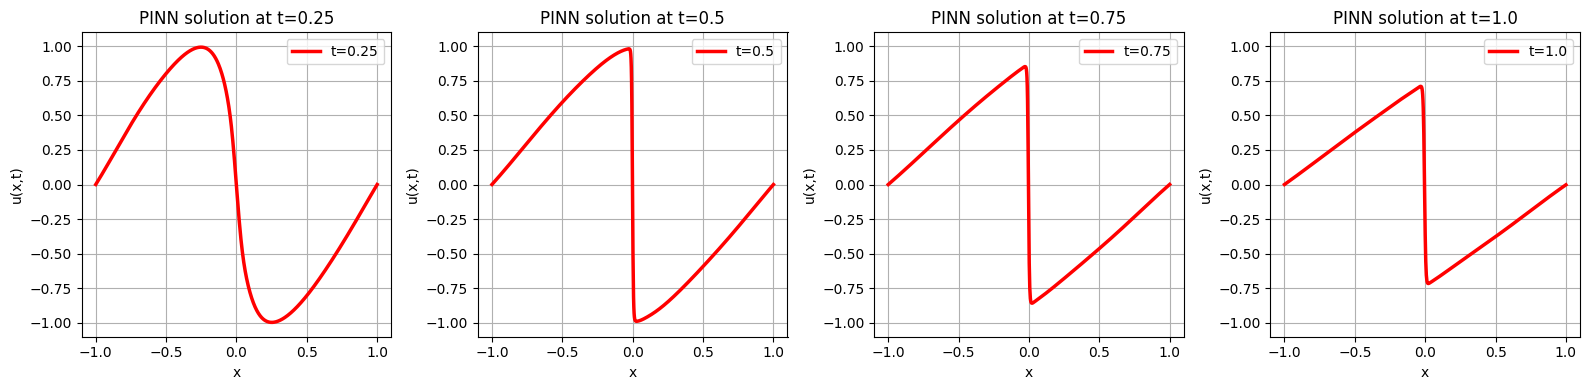

In [32]:
#Πλήθος διαστημάτων
N = 1000

#tmin = tmin.cpu().item()
#tmax = tmax.cpu().item()
#xmin = xmin.cpu().item()
#xmax = xmax.cpu().item()

#Δημιουργία σημείων
tspace_shot = np.array([0.25, 0.50, 0.75, 1.00]) #(4,1)
xspace_shot = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T_shot, X_shot = np.meshgrid(tspace_shot, xspace_shot) #(4,N+1) , (4,N+1)

#κάθε γραμμή ένα σημείο του πλέγματος
Xgrid_shot = np.vstack([T_shot.flatten(),X_shot.flatten()]).T #((Ν+1)x4,2)

#Υπολογίζει τις προβλέψεις u(t, x) του μοντέλου
upred_shot = model(torch.tensor(Xgrid_shot,dtype=dtype).to(device)) #((Ν+1)^2,1)

#Από ((Ν+1)^2,1) σε (Ν+1,Ν+1)
U_shot = upred_shot.cpu().detach().numpy().reshape(len(xspace_shot), len(tspace_shot))

n_t = len(tspace_shot)
fig, axes = plt.subplots(1, n_t, figsize=(4*n_t, 4))  # 1 σειρά, n_t στήλες

x_min_shot, x_max_shot = -1, 1
u_min_shot, u_max_shot = -1, 1

buffer_x_shot = 0.05*(x_max_shot - x_min_shot)
buffer_u_shot = 0.05*(u_max_shot - u_min_shot)

for i, t_val in enumerate(tspace_shot):
  u_pred_shot = U_shot[:, i]   # κάθε στήλη = t_val
  ax = axes[i]                 # ορίστε σωστά τον άξονα για αυτό το subplot
  ax.plot(xspace_shot, u_pred_shot, label=f't={tspace_shot[i]}', color= 'red', linewidth=2.5)
  ax.set_xlabel('x')
  ax.set_ylabel('u(x,t)')
  ax.set_title(f'PINN solution at t={tspace_shot[i]}')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(x_min_shot - buffer_x_shot, x_max_shot + buffer_x_shot)
  ax.set_ylim(u_min_shot - buffer_u_shot, u_max_shot + buffer_u_shot)

plt.tight_layout()
plt.show()

<>:8: SyntaxWarning:

invalid escape sequence '\i'

<>:8: SyntaxWarning:

invalid escape sequence '\i'

/tmp/ipython-input-1716786821.py:8: SyntaxWarning:

invalid escape sequence '\i'

/tmp/ipython-input-1716786821.py:14: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)

/tmp/ipython-input-1716786821.py:17: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)

/tmp/ipython-input-1716786821.py:18: DeprecationWarning:

__array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)



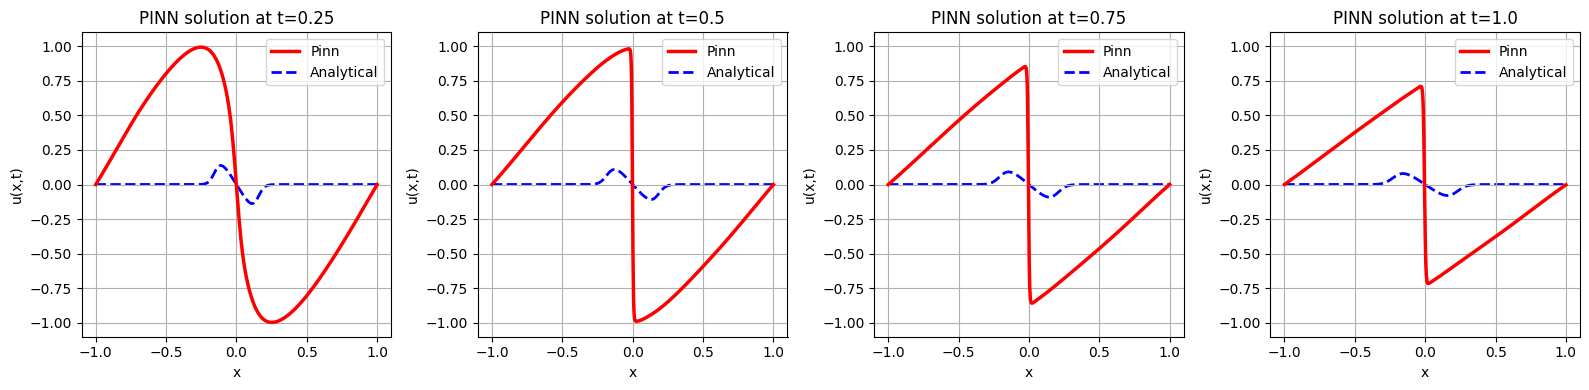

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive # Τροποποιημένη συνάρτηση Bessel πρώτου είδους

def burgers_analytical(x, t, nu, n_terms=200):
    """
    Υπολογισμός της αναλυτικής λύσης της εξίσωσης Burgers.
    u(x,0) = -sin(pi*x) στο x \in [-1, 1]
    """
    # Συντελεστής για τη συνάρτηση Bessel
    z = 1.0 / (2 * np.pi * nu)

    numerator = 0.0
    denominator = ive(0, z)

    for n in range(1, n_terms):
        In = ive(n, z)
        exp_term = np.exp(-n**2 * np.pi**2 * nu * t)

        numerator += n * In * exp_term * np.sin(n * np.pi * x)
        denominator += In * exp_term * np.cos(n * np.pi * x)

    return -2 * np.pi * nu * (numerator / denominator)

#Πλήθος διαστημάτων
N = 1000

#tmin = tmin.cpu().item()
#tmax = tmax.cpu().item()
#xmin = xmin.cpu().item()
#xmax = xmax.cpu().item()

#Δημιουργία σημείων
tspace_shot = np.array([0.25, 0.50, 0.75, 1.00]) #(4,1)
xspace_shot = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T_shot, X_shot = np.meshgrid(tspace_shot, xspace_shot) #(4,N+1) , (4,N+1)

#κάθε γραμμή ένα σημείο του πλέγματος
Xgrid_shot = np.vstack([T_shot.flatten(),X_shot.flatten()]).T #((Ν+1)x4,2)

#Υπολογίζει τις προβλέψεις u(t, x) του μοντέλου
upred_shot = model(torch.tensor(Xgrid_shot,dtype=dtype).to(device)) #((Ν+1)^2,1)

#Από ((Ν+1)^2,1) σε (Ν+1,Ν+1)
U_shot = upred_shot.cpu().detach().numpy().reshape(len(xspace_shot), len(tspace_shot))

n_t = len(tspace_shot)
fig, axes = plt.subplots(1, n_t, figsize=(4*n_t, 4))  # 1 σειρά, n_t στήλες

x_min_shot, x_max_shot = -1, 1
u_min_shot, u_max_shot = -1, 1

buffer_x_shot = 0.05*(x_max_shot - x_min_shot)
buffer_u_shot = 0.05*(u_max_shot - u_min_shot)

for i, t_val in enumerate(tspace_shot):
  u_pred_shot = U_shot[:, i]   # κάθε στήλη = t_val
  ax = axes[i]                 # ορίστε σωστά τον άξονα για αυτό το subplot

  ax.plot(xspace_shot, u_pred_shot, color= 'r', linewidth=2.5, label='Pinn')

  u_anal = np.array([burgers_analytical(x_val, t_val, viscosity) for x_val in xspace_shot])
  ax.plot(xspace_shot, u_anal, color='b', linestyle='--', linewidth=2.0, label='Analytical', zorder=1)

  ax.set_xlabel('x')
  ax.set_ylabel('u(x,t)')
  ax.set_title(f'PINN solution at t={tspace_shot[i]}')
  ax.grid(True)
  ax.legend()
  ax.set_xlim(x_min_shot - buffer_x_shot, x_max_shot + buffer_x_shot)
  ax.set_ylim(u_min_shot - buffer_u_shot, u_max_shot + buffer_u_shot)

plt.tight_layout()
plt.show()

<>:8: SyntaxWarning:

invalid escape sequence '\i'

<>:8: SyntaxWarning:

invalid escape sequence '\i'

/tmp/ipython-input-89095877.py:8: SyntaxWarning:

invalid escape sequence '\i'



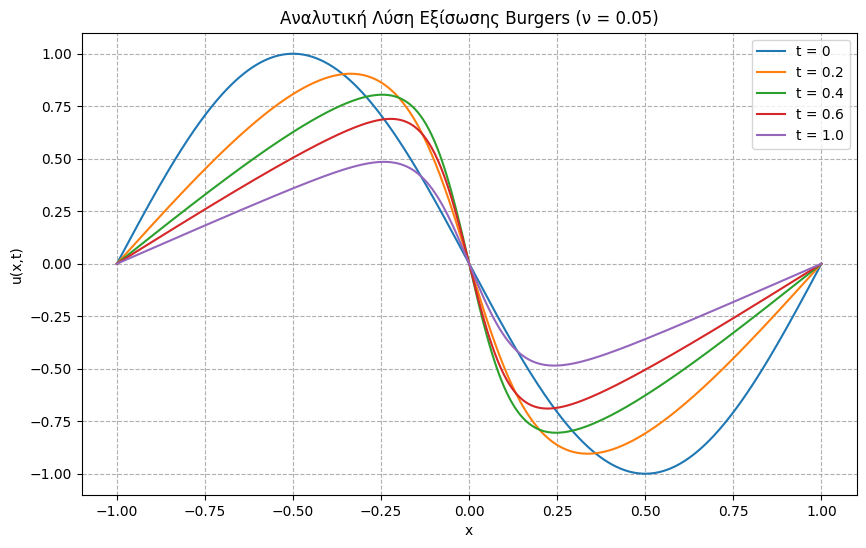

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv # Τροποποιημένη συνάρτηση Bessel πρώτου είδους

def burgers_analytical(x, t, nu, n_terms=50):
    """
    Υπολογισμός της αναλυτικής λύσης της εξίσωσης Burgers.
    u(x,0) = -sin(pi*x) στο x \in [-1, 1]
    """
    # Συντελεστής για τη συνάρτηση Bessel
    z = 1.0 / (2 * np.pi * nu)

    # Απαριθμητής και παρονομαστής της λύσης
    numerator = 0
    denominator = iv(0, z) # Ο όρος a0

    for n in range(1, n_terms):
        an = 2 * ((-1)**n) * iv(n, z)
        exp_term = np.exp(-(n**2) * (np.pi**2) * nu * t)

        numerator += n * an * exp_term * np.sin(n * np.pi * x)
        denominator += an * exp_term * np.cos(n * np.pi * x)

    return 2 * np.pi * nu * (numerator / denominator)

# Παράμετροι
nu = 0.05  # Ιξώδες (μικρότερο nu = πιο απότομο shock)
x = np.linspace(-1, 1, 500)
times = [0, 0.2, 0.4, 0.6, 1.0]

# Σχεδίαση
plt.figure(figsize=(10, 6))
for t in times:
    u = [burgers_analytical(xi, t, nu) for xi in x]
    plt.plot(x, u, label=f't = {t}')

plt.title(f'Αναλυτική Λύση Εξίσωσης Burgers (ν = {nu})')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()